# EDA - Housing Dataset

Den här notebooken är en Jupyter-version av `eda_housing.py`. Kör cellerna uppifrån och ned. Filen `housing.csv` behöver ligga i samma mapp som notebooken. Om filen ligger någon annanstans kan du ändra `DATA_FILE` i inläsningscellen.


## Förberedelser

Importera de bibliotek som används i analysen.


In [9]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


## Hjälpfunktion

Funktionen försöker hitta en rimlig priskolumn, eftersom olika housing-dataset kan använda olika kolumnnamn.


In [10]:
def find_price_column(df):
    possible_price_columns = ["price", "Price", "median_house_value", "SalePrice", "sale_price"]

    for col in possible_price_columns:
        if col in df.columns:
            return col

    return None


## 1. Läs in datasetet

Läs in `housing.csv` och kontrollera datasetets struktur.


In [11]:
DATA_FILE = Path("housing.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Hittar inte {DATA_FILE}. Lägg housing.csv i samma mapp som notebooken "
        "eller ändra DATA_FILE till rätt sökväg."
    )

df = pd.read_csv(DATA_FILE)

print("De första 5 raderna i datasetet:")
display(df.head())

print("Antal rader och kolumner:")
print(df.shape)

print("Information om datasetet:")
df.info()

print("Statistisk sammanfattning:")
display(df.describe())


De första 5 raderna i datasetet:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Antal rader och kolumner:
(20640, 10)
Information om datasetet:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
Statistisk sammanfattning:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2. Kontrollera saknade värden

Undersök om datasetet har saknade värden och visualisera de kolumner som saknar data.


Saknade värden per kolumn:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

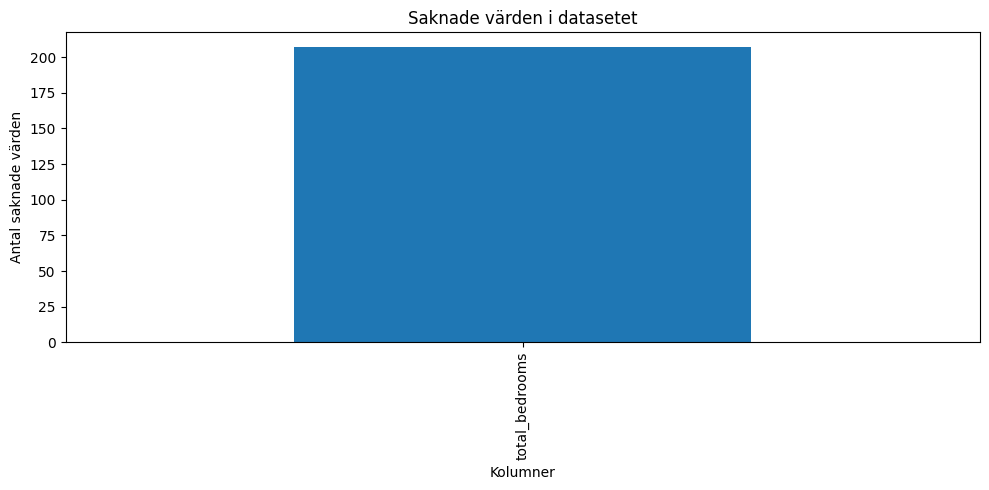

In [12]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

if "df" not in globals():
    DATA_FILE = Path("housing.csv")

    if not DATA_FILE.exists():
        raise FileNotFoundError(
            f"Hittar inte {DATA_FILE}. Lägg housing.csv i samma mapp som notebooken "
            "eller ändra DATA_FILE till rätt sökväg."
        )

    df = pd.read_csv(DATA_FILE)

missing_values = df.isnull().sum()

print("Saknade värden per kolumn:")
display(missing_values)

if (missing_values > 0).any():
    plt.figure(figsize=(10, 5))
    missing_values[missing_values > 0].plot(kind="bar")
    plt.title("Saknade värden i datasetet")
    plt.xlabel("Kolumner")
    plt.ylabel("Antal saknade värden")
    plt.tight_layout()
    plt.show()
else:
    print("Datasetet har inga saknade värden.")


## 3. Kontrollera datatyper

Visa vilken datatyp varje kolumn har.


In [13]:
print("Datatyper:")
display(df.dtypes)


Datatyper:


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

## 4. Undersök priskolumnen

Hitta priskolumnen, visa statistik, histogram, boxplot och exempel på billigaste och dyraste hus.


Priskolumn som används: median_house_value
Statistik för priser:


count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

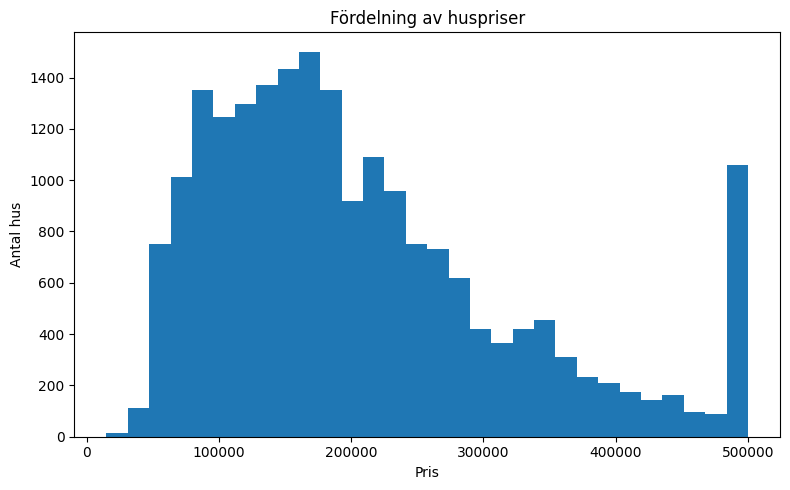

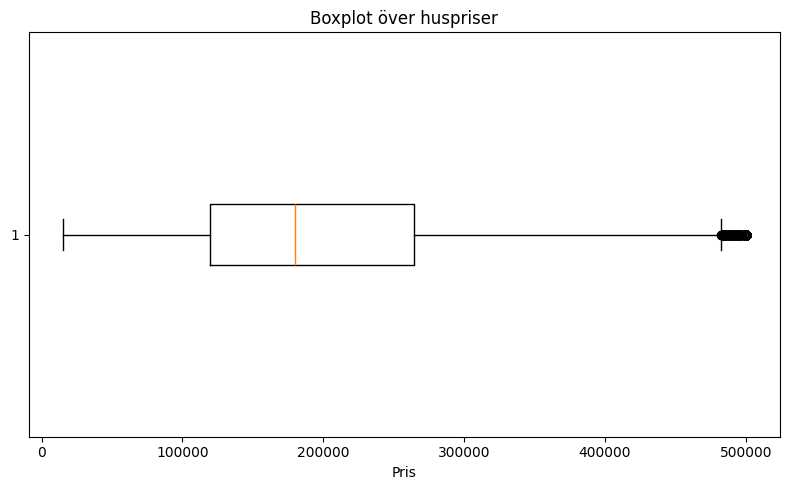

De 10 billigaste husen:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9188,-117.86,34.24,52.0,803.0,267.0,628.0,225.0,4.1932,14999.0,INLAND
19802,-123.17,40.31,36.0,98.0,28.0,18.0,8.0,0.5360,14999.0,INLAND
2799,-117.02,36.40,19.0,619.0,239.0,490.0,164.0,2.1000,14999.0,INLAND
2521,-122.74,39.71,16.0,255.0,73.0,85.0,38.0,1.6607,14999.0,INLAND
5887,-118.33,34.15,39.0,493.0,168.0,259.0,138.0,2.3667,17500.0,<1H OCEAN
1825,-122.32,37.93,33.0,296.0,73.0,216.0,63.0,2.6750,22500.0,NEAR BAY
13889,-116.57,35.43,8.0,9975.0,1743.0,6835.0,1439.0,2.7138,22500.0,INLAND
14326,-117.16,32.71,52.0,845.0,451.0,1230.0,375.0,1.0918,22500.0,NEAR OCEAN
16186,-121.29,37.95,52.0,107.0,79.0,167.0,53.0,0.7917,22500.0,INLAND
2779,-114.65,32.79,21.0,44.0,33.0,64.0,27.0,0.8571,25000.0,INLAND


De 10 dyraste husen:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10667,-117.88,33.55,27.0,2278.0,316.0,772.0,304.0,10.1275,500001.0,<1H OCEAN
16916,-122.34,37.57,52.0,2635.0,408.0,967.0,374.0,7.0422,500001.0,NEAR OCEAN
16946,-122.33,37.55,33.0,2199.0,312.0,827.0,319.0,6.1349,500001.0,NEAR OCEAN
8877,-118.49,34.04,48.0,2381.0,345.0,859.0,306.0,8.0257,500001.0,<1H OCEAN
8878,-118.50,34.04,52.0,3000.0,374.0,1143.0,375.0,15.0001,500001.0,<1H OCEAN
8879,-118.50,34.04,52.0,2233.0,317.0,769.0,277.0,8.3839,500001.0,<1H OCEAN
16941,-122.34,37.55,44.0,2465.0,328.0,843.0,324.0,6.9533,500001.0,NEAR OCEAN
16940,-122.33,37.55,51.0,2565.0,332.0,870.0,309.0,9.3694,500001.0,NEAR OCEAN
16939,-122.32,37.55,50.0,2501.0,433.0,1050.0,410.0,4.6406,500001.0,NEAR OCEAN
16938,-122.33,37.56,50.0,1975.0,245.0,644.0,251.0,10.0743,500001.0,NEAR OCEAN


In [14]:
price_column = find_price_column(df)

if price_column is None:
    print("Ingen tydlig priskolumn hittades.")
    print("Kolumner i datasetet är:")
    print(df.columns)
else:
    print(f"Priskolumn som används: {price_column}")

    print("Statistik för priser:")
    display(df[price_column].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(df[price_column].dropna(), bins=30)
    plt.title("Fördelning av huspriser")
    plt.xlabel("Pris")
    plt.ylabel("Antal hus")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.boxplot(df[price_column].dropna(), vert=False)
    plt.title("Boxplot över huspriser")
    plt.xlabel("Pris")
    plt.tight_layout()
    plt.show()

    print("De 10 billigaste husen:")
    display(df.sort_values(by=price_column).head(10))

    print("De 10 dyraste husen:")
    display(df.sort_values(by=price_column, ascending=False).head(10))


## 5. Undersök numeriska kolumner

Välj ut numeriska kolumner och visa histogram för dem.


Numeriska kolumner:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


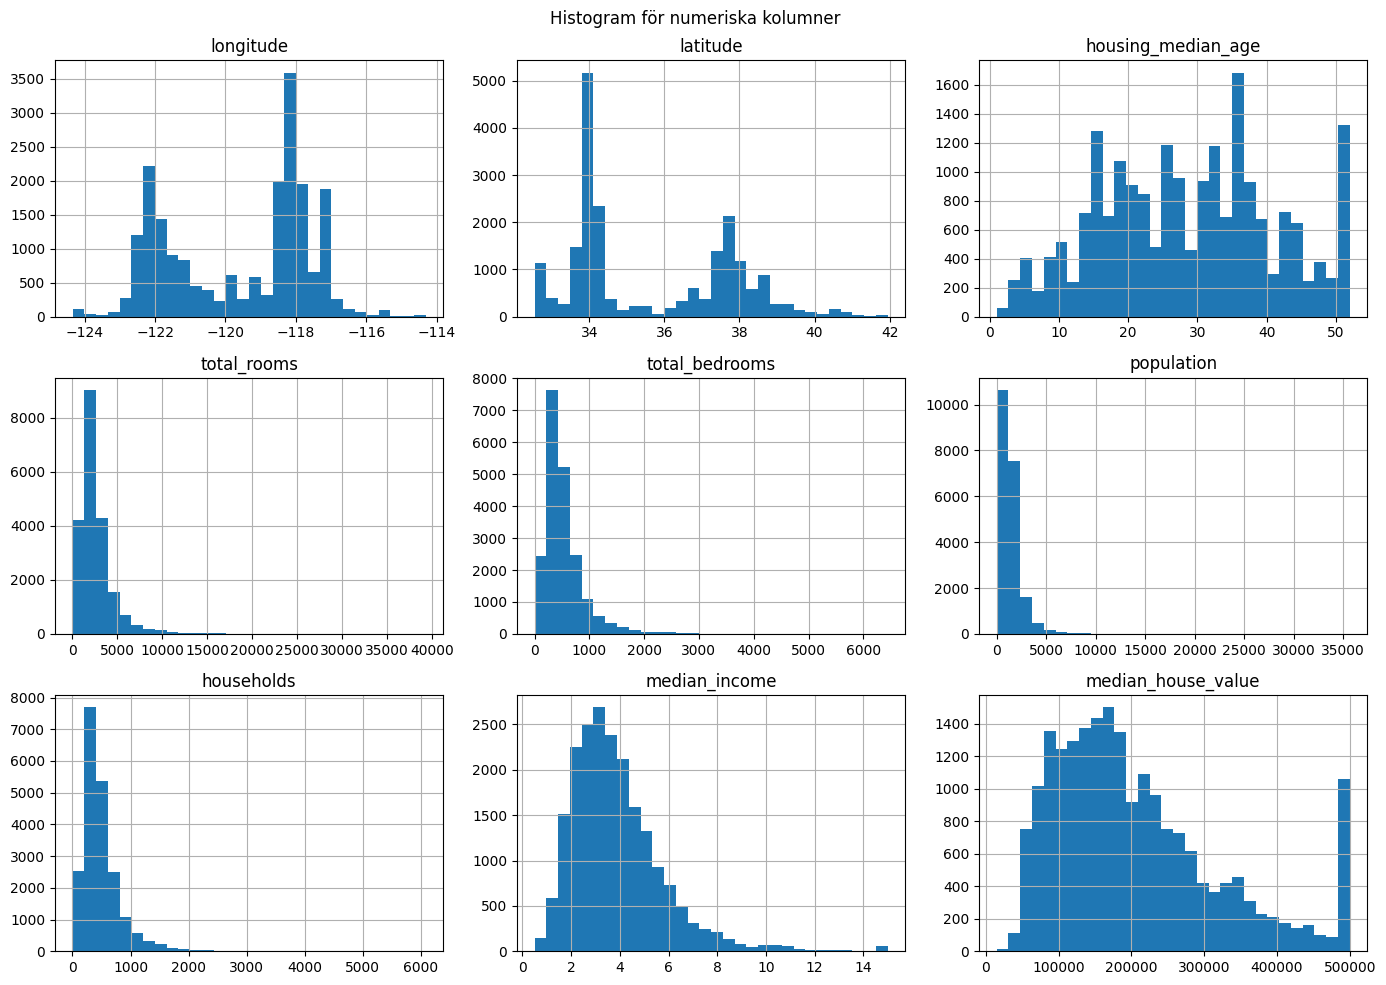

In [ ]:
numeric_columns = df.select_dtypes(include=["number"]).columns

print("Numeriska kolumner:")
print(list(numeric_columns))

if len(numeric_columns) > 0:
    df[numeric_columns].hist(figsize=(14, 10), bins=30)
    plt.suptitle("Histogram för numeriska kolumner")
    plt.tight_layout()
    plt.show()
else:
    print("Datasetet har inga numeriska kolumner.")


## 6. Samband mellan variabler

Räkna ut korrelationen mellan pris och andra numeriska variabler.


Korrelation med pris:


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

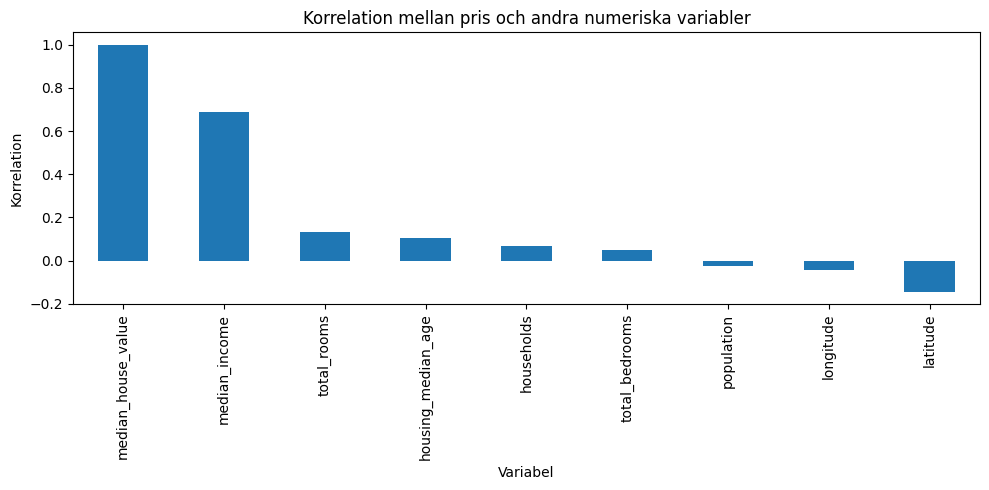

In [ ]:
correlations = None

if price_column is not None and price_column in numeric_columns and len(numeric_columns) > 1:
    correlations = df[numeric_columns].corr()

    print("Korrelation med pris:")
    display(correlations[price_column].sort_values(ascending=False))

    price_corr = correlations[price_column].sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    price_corr.plot(kind="bar")
    plt.title("Korrelation mellan pris och andra numeriska variabler")
    plt.xlabel("Variabel")
    plt.ylabel("Korrelation")
    plt.tight_layout()
    plt.show()
elif price_column is None:
    print("Ingen priskolumn hittades, därför går korrelation med pris inte att visa.")
else:
    print("Priskolumnen är inte numerisk eller det finns för få numeriska kolumner.")


## 7. Scatter plots

Skapa scatter plots för att se samband mellan priset och andra numeriska variabler.


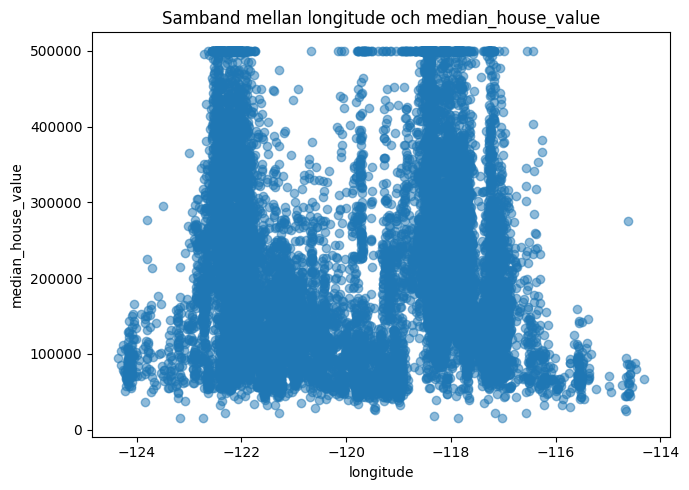

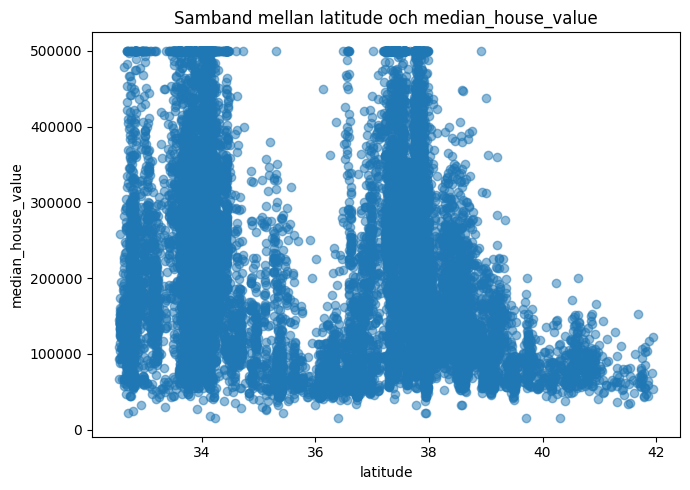

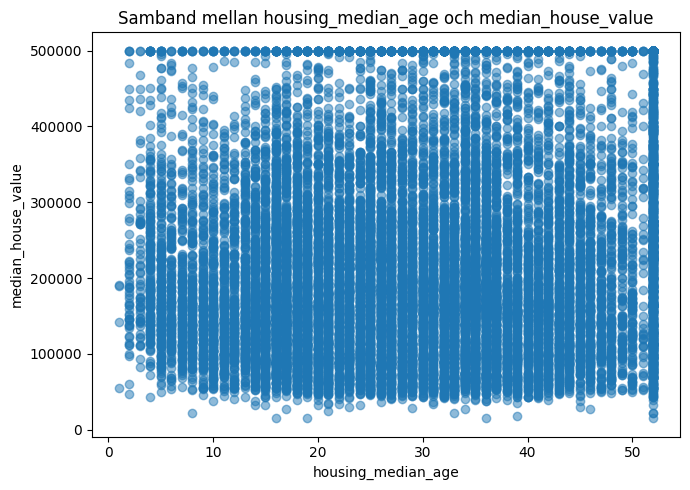

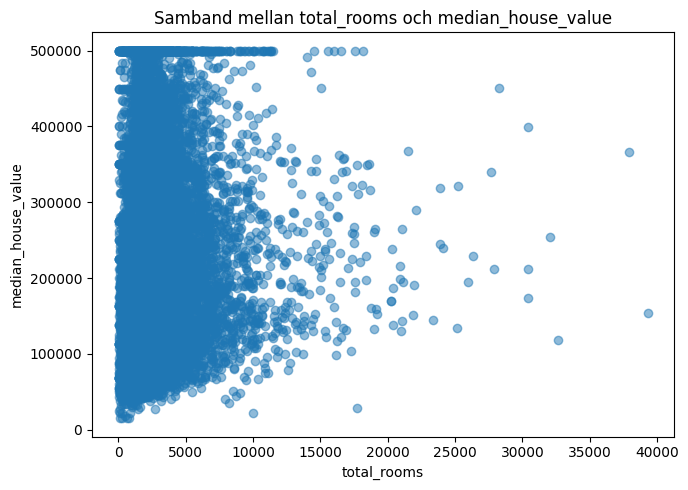

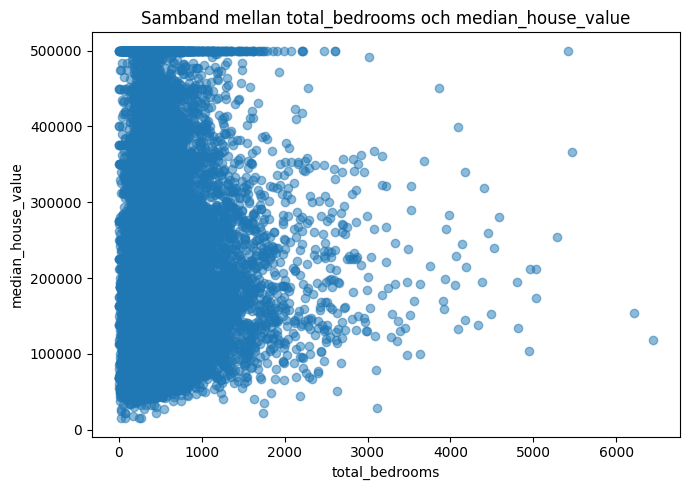

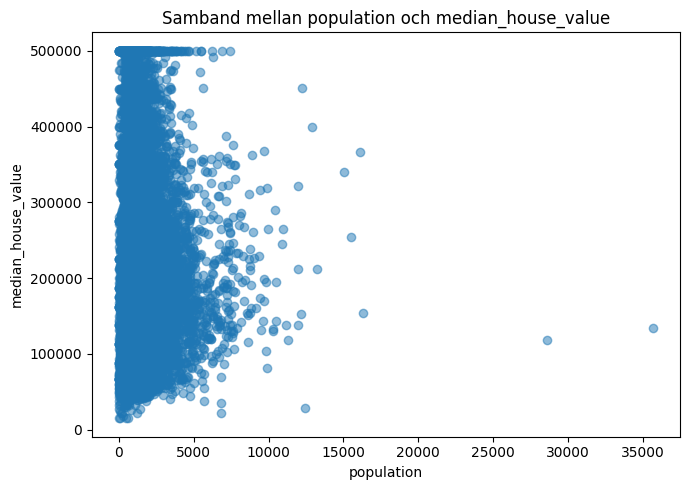

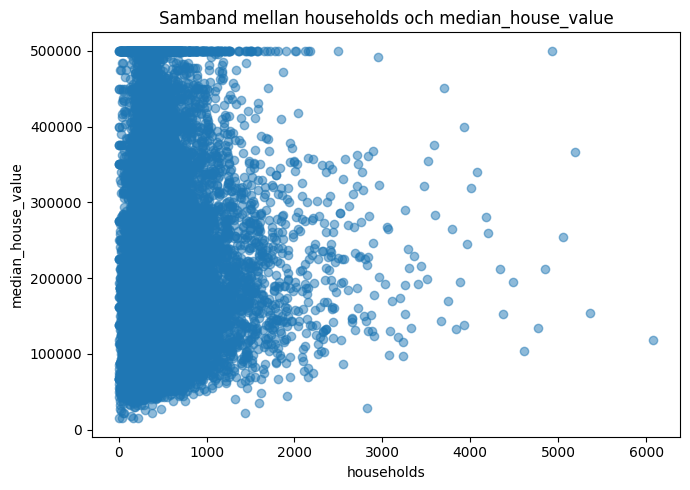

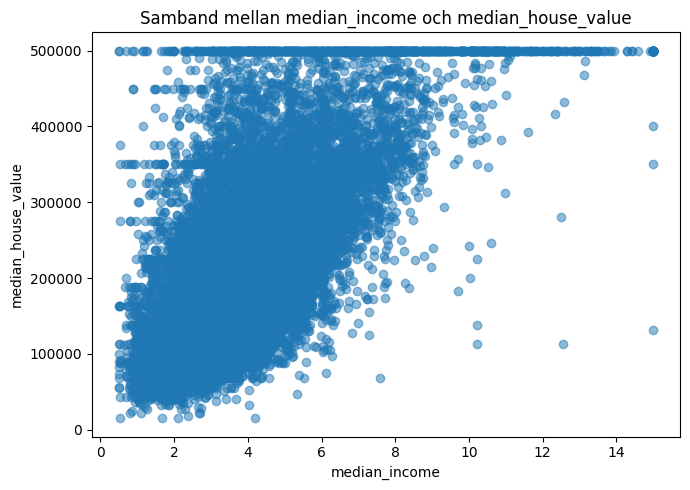

In [ ]:
if price_column is not None and price_column in numeric_columns:
    for col in numeric_columns:
        if col != price_column:
            plt.figure(figsize=(7, 5))
            plt.scatter(df[col], df[price_column], alpha=0.5)
            plt.title(f"Samband mellan {col} och {price_column}")
            plt.xlabel(col)
            plt.ylabel(price_column)
            plt.tight_layout()
            plt.show()
else:
    print("Ingen numerisk priskolumn hittades, därför skapas inga scatter plots mot pris.")


## 8. Hantera saknade värden

Fyll numeriska saknade värden med median och textvärden med vanligaste värdet.


In [ ]:
print("Antal saknade värden innan bearbetning:")
display(df.isnull().sum())

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_columns:
    mode_values = df[col].mode(dropna=True)
    if not mode_values.empty:
        df[col] = df[col].fillna(mode_values.iloc[0])

print("Antal saknade värden efter bearbetning:")
display(df.isnull().sum())


Antal saknade värden innan bearbetning:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Antal saknade värden efter bearbetning:


/var/folders/kz/4x9bxdzn0_z99r516mcmqjh00000gn/T/ipykernel_97777/1613572385.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 9. Undersök kategoriska variabler

Visa kategoriska kolumner och de vanligaste värdena i varje kolumn.


Kategoriska kolumner:
['ocean_proximity']
Antal unika värden i ocean_proximity:


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

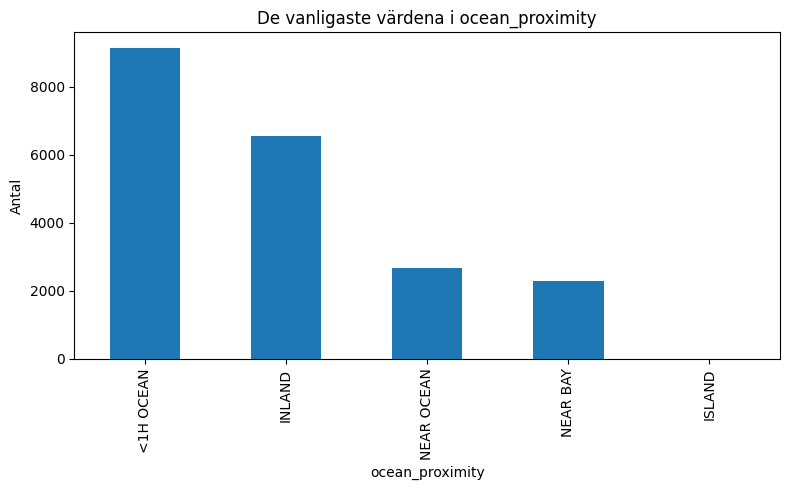

In [ ]:
print("Kategoriska kolumner:")
print(list(categorical_columns))

if len(categorical_columns) == 0:
    print("Datasetet har inga kategoriska kolumner.")

for col in categorical_columns:
    print(f"Antal unika värden i {col}:")
    counts = df[col].value_counts()
    display(counts)

    if not counts.empty:
        plt.figure(figsize=(8, 5))
        counts.head(10).plot(kind="bar")
        plt.title(f"De vanligaste värdena i {col}")
        plt.xlabel(col)
        plt.ylabel("Antal")
        plt.tight_layout()
        plt.show()


## 10. Slutsats

Sammanfatta analysen och visa de variabler som verkar ha starkast samband med priset.


In [ ]:
print("SLUTSATS:")
print("Denna EDA undersöker datasetets struktur, saknade värden, prisfördelning,")
print("samband mellan variabler och vilka faktorer som kan påverka om ett hus är dyrare eller billigare.")

if price_column is not None and correlations is not None:
    strongest_corr = correlations[price_column].sort_values(ascending=False)
    print("Variabler som verkar ha starkast samband med priset:")
    display(strongest_corr.head(5))

    print("Tolkning:")
    print("Hus med högre värden på variabler som har stark positiv korrelation med priset")
    print("tenderar att vara dyrare. Variabler med negativ korrelation kan däremot")
    print("hänga ihop med lägre huspriser.")
else:
    print("Ingen priskorrelation kunde visas eftersom priskolumn saknas eller inte är numerisk.")


SLUTSATS:
Denna EDA undersöker datasetets struktur, saknade värden, prisfördelning,
samband mellan variabler och vilka faktorer som kan påverka om ett hus är dyrare eller billigare.
Variabler som verkar ha starkast samband med priset:


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
Name: median_house_value, dtype: float64

Tolkning:
Hus med högre värden på variabler som har stark positiv korrelation med priset
tenderar att vara dyrare. Variabler med negativ korrelation kan däremot
hänga ihop med lägre huspriser.
